# NLP 대회 자료 Review
## 개체명인식 대회 · 데이콘 · 캐글 종합 분석

---

## 리뷰 대상 대회

### 🔵 개체명인식 (NER) 대회
| 대회명 | 주최 | 언어 | 태그 | 평가 지표 |
|--------|------|------|------|-----------|
| **KLUE NER** | 업스테이지/카카오 | 한국어 | 13개 클래스 | Entity-F1 |
| **CoNLL-2003** | CoNLL | 영어/독어 | 4개 클래스 | Entity-F1 |
| **NAVER NER** | 네이버 | 한국어 | 14개 클래스 | Entity-F1 |
| **KMOU NER** | 한국해양대 | 한국어 | 10개 클래스 | Entity-F1 |

### 🟠 데이콘 (DACON) NLP 대회
| 대회명 | 유형 | 평가 지표 | 특징 |
|--------|------|-----------|------|
| **월간 데이콘 감성분석** | 텍스트 분류 | F1 Score | 영화 리뷰 긍/부정 |
| **법률 문서 AI 분석** | NLI/QA | F1 | 법령 조항 이해 |
| **대화 요약 AI** | 요약 | ROUGE | 대화문 → 요약 |

### 🟢 캐글 (Kaggle) NLP 대회
| 대회명 | 유형 | 평가 지표 | 상금 |
|--------|------|-----------|------|
| **Jigsaw Toxic Comment** | 텍스트 분류 | AUC-ROC | $35,000 |
| **Feedback Prize NER** | NER/분류 | Macro F1 | $30,000 |
| **CommonLit Readability** | 회귀 | RMSE | $60,000 |
| **NBME Clinical NER** | NER | Micro F1 | $30,000 |
| **Disaster Tweets** | 분류 | F1 | 지식 대회 |

---

##  이번 분석에서 다루는 것
```
1. 각 대회 데이터 구조 분석
2. 평가 지표 (Entity F1, ROUGE, AUC) 직접 구현
3. 대회별 베이스라인 모델 구현
4. 수상 솔루션 핵심 기법 분석
5. 실전 제출 파일 포맷 실습
```

In [1]:
# 필요 라이브러리 설치
!pip install transformers datasets seqeval rouge-score scikit-learn pandas numpy matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter, defaultdict
import re, json, os, random, warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['axes.unicode_minus'] = False

random.seed(42)
np.random.seed(42)

print('✅ 라이브러리 로드 완료')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
✅ 라이브러리 로드 완료


---
# 🔵 PART 1. 개체명인식(NER) 대회 리뷰

## 1-1. KLUE NER 대회 분석

### 대회 개요
- **주최**: 업스테이지 (AIHub 공개 데이터 기반)
- **목표**: 한국어 문장에서 13가지 개체명 인식
- **데이터**: 뉴스 기사, 위키피디아 등
- **평가**: Character-level Entity F1

### KLUE NER 13개 태그 클래스
```
PS  (인물)     LC  (지명)     OG  (기관)     DT  (날짜)
TI  (시간)     QT  (수량)     EV  (사건)     FD  (분야)
TR  (이론)     AF  (인공물)   AM  (동물)     PT  (식물)
CV  (문명/문화)
```

In [2]:
# ── KLUE NER 데이터 구조 시뮬레이션 ──────────────────────────
# 실제 KLUE 데이터셋 형식을 재현

KLUE_NER_CLASSES = {
    'PS': '인물',   'LC': '지명',   'OG': '기관',   'DT': '날짜',
    'TI': '시간',   'QT': '수량',   'EV': '사건',   'FD': '분야',
    'TR': '이론',   'AF': '인공물', 'AM': '동물',   'PT': '식물',
    'CV': '문명/문화'
}

# KLUE NER 샘플 데이터 (JSON Lines 형식)
KLUE_SAMPLES = [
    {
        'sentence': '이순신은 조선의 장군으로 임진왜란에서 활약하였다.',
        'entities': [
            {'text': '이순신', 'type': 'PS', 'start': 0,  'end': 3},
            {'text': '조선',   'type': 'OG', 'start': 5,  'end': 7},
            {'text': '임진왜란', 'type': 'EV', 'start': 12, 'end': 16},
        ]
    },
    {
        'sentence': '삼성전자는 서울 강남구에 위치하며 2023년에 기록적인 매출을 올렸다.',
        'entities': [
            {'text': '삼성전자',    'type': 'OG', 'start': 0,  'end': 4},
            {'text': '서울 강남구',  'type': 'LC', 'start': 5,  'end': 11},
            {'text': '2023년',      'type': 'DT', 'start': 13, 'end': 18},
        ]
    },
    {
        'sentence': '김연아 선수는 2010년 밴쿠버 동계올림픽에서 금메달을 획득했다.',
        'entities': [
            {'text': '김연아',        'type': 'PS', 'start': 0,  'end': 3},
            {'text': '2010년',        'type': 'DT', 'start': 8,  'end': 13},
            {'text': '밴쿠버',        'type': 'LC', 'start': 14, 'end': 17},
            {'text': '동계올림픽',    'type': 'EV', 'start': 18, 'end': 23},
        ]
    },
    {
        'sentence': '카카오는 제주도에 본사를 두고 인공지능 기술을 연구하고 있다.',
        'entities': [
            {'text': '카카오',   'type': 'OG', 'start': 0, 'end': 3},
            {'text': '제주도',   'type': 'LC', 'start': 4, 'end': 7},
            {'text': '인공지능', 'type': 'FD', 'start': 15, 'end': 19},
        ]
    },
]

# KLUE NER 데이터를 IOB2 형식으로 변환
def klue_to_iob2(sample):
    """KLUE 스팬 형식 → IOB2 토큰 형식"""
    sentence = sample['sentence']
    entities = sample['entities']

    # 문자 단위 태그 초기화
    char_tags = ['O'] * len(sentence)
    for ent in entities:
        for i in range(ent['start'], ent['end']):
            if i == ent['start']:
                char_tags[i] = f'B-{ent["type"]}'
            else:
                char_tags[i] = f'I-{ent["type"]}'

    # 공백 기준 토큰화 (간단 버전)
    tokens, tags = [], []
    for char, tag in zip(sentence, char_tags):
        if char != ' ':
            tokens.append(char)
            tags.append(tag)
    return tokens, tags


print('[KLUE NER 데이터 구조 분석]\n')
print(f'클래스 수: {len(KLUE_NER_CLASSES)}개')
print(f'클래스 목록: {KLUE_NER_CLASSES}\n')

for sample in KLUE_SAMPLES[:2]:
    print(f'문장: {sample["sentence"]}')
    for ent in sample['entities']:
        emoji_map = {'PS':'👤','OG':'🏢','LC':'📍','DT':'📅','EV':'📰','FD':'🔬'}
        emoji = emoji_map.get(ent['type'], '•')
        print(f'  {emoji} [{ent["type"]}:{KLUE_NER_CLASSES[ent["type"]]}] "{ent["text"]}" ({ent["start"]}~{ent["end"]})')
    print()

[KLUE NER 데이터 구조 분석]

클래스 수: 13개
클래스 목록: {'PS': '인물', 'LC': '지명', 'OG': '기관', 'DT': '날짜', 'TI': '시간', 'QT': '수량', 'EV': '사건', 'FD': '분야', 'TR': '이론', 'AF': '인공물', 'AM': '동물', 'PT': '식물', 'CV': '문명/문화'}

문장: 이순신은 조선의 장군으로 임진왜란에서 활약하였다.
  👤 [PS:인물] "이순신" (0~3)
  🏢 [OG:기관] "조선" (5~7)
  📰 [EV:사건] "임진왜란" (12~16)

문장: 삼성전자는 서울 강남구에 위치하며 2023년에 기록적인 매출을 올렸다.
  🏢 [OG:기관] "삼성전자" (0~4)
  📍 [LC:지명] "서울 강남구" (5~11)
  📅 [DT:날짜] "2023년" (13~18)



## 1-2. NER 대회 핵심 평가지표 — Entity-level F1

### Span-level (엄격) vs Token-level (완화)
```
예측: ['삼성전자'(ORG), '강남구'(LOC)]
정답: ['삼성전자'(ORG), '서울 강남구'(LOC)]

Span-level: '강남구' ≠ '서울 강남구' → LOC 불일치 → F1 낮아짐
Token-level: '강남'(O→I-LOC), '구'(I-LOC) 중 일부만 맞음
```
**대회 기준: 시작·끝 위치와 타입 모두 일치해야 정답**

In [3]:
# seqeval 라이브러리로 NER 평가
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from seqeval.metrics import sequence_labeling as seq_label

# 예측 vs 정답 시뮬레이션
y_true = [
    ['B-PS', 'I-PS', 'O', 'B-OG', 'O', 'O', 'O'],
    ['O', 'B-DT', 'O', 'B-LC', 'I-LC', 'O'],
    ['B-PS', 'I-PS', 'O', 'B-EV', 'I-EV', 'O'],
    ['B-OG', 'I-OG', 'I-OG', 'O', 'B-LC', 'O', 'B-DT', 'O'],
]
y_pred = [
    ['B-PS', 'I-PS', 'O', 'B-OG', 'O', 'O', 'O'],   # 완벽
    ['O', 'B-DT', 'O', 'B-LC', 'O', 'O'],             # LC 경계 오류
    ['B-PS', 'O', 'O', 'B-EV', 'I-EV', 'O'],          # PS 경계 오류
    ['B-OG', 'I-OG', 'I-OG', 'O', 'B-LC', 'O', 'B-DT', 'O'],  # 완벽
]

print('[NER Entity-level F1 평가]\n')
print(f'Entity-level Precision : {precision_score(y_true, y_pred):.4f}')
print(f'Entity-level Recall    : {recall_score(y_true, y_pred):.4f}')
print(f'Entity-level F1 Score  : {f1_score(y_true, y_pred):.4f}')
print()
print('[클래스별 상세 리포트]')
print(classification_report(y_true, y_pred))


# Entity F1 직접 구현 (대회 공식 수식 이해)
def entity_f1_manual(y_true_list, y_pred_list):
    """Entity-level F1을 직접 계산 (대회 평가 코드 이해용)"""
    def get_entities(tag_seq):
        """IOB2 시퀀스에서 (타입, 시작, 끝) 집합 추출"""
        ents = set()
        cur_type, start = None, None
        for i, tag in enumerate(tag_seq):
            if tag.startswith('B-'):
                if cur_type: ents.add((cur_type, start, i-1))
                cur_type, start = tag[2:], i
            elif tag.startswith('I-') and cur_type == tag[2:]:
                pass
            else:
                if cur_type: ents.add((cur_type, start, i-1))
                cur_type, start = None, None
        if cur_type: ents.add((cur_type, start, len(tag_seq)-1))
        return ents

    tp = fp = fn = 0
    for true_seq, pred_seq in zip(y_true_list, y_pred_list):
        true_ents = get_entities(true_seq)
        pred_ents = get_entities(pred_seq)
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)

    prec = tp / (tp + fp) if tp + fp > 0 else 0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0
    return {'precision': prec, 'recall': rec, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}

manual_result = entity_f1_manual(y_true, y_pred)
print('[수식 직접 구현 검증]')
print(f'  TP={manual_result["tp"]} FP={manual_result["fp"]} FN={manual_result["fn"]}')
print(f'  F1 = {manual_result["f1"]:.4f}  (seqeval과 동일: {abs(manual_result["f1"] - f1_score(y_true, y_pred)) < 0.001})')

[NER Entity-level F1 평가]

Entity-level Precision : 0.7778
Entity-level Recall    : 0.7778
Entity-level F1 Score  : 0.7778

[클래스별 상세 리포트]
              precision    recall  f1-score   support

          DT       1.00      1.00      1.00         2
          EV       1.00      1.00      1.00         1
          LC       0.50      0.50      0.50         2
          OG       1.00      1.00      1.00         2
          PS       0.50      0.50      0.50         2

   micro avg       0.78      0.78      0.78         9
   macro avg       0.80      0.80      0.80         9
weighted avg       0.78      0.78      0.78         9

[수식 직접 구현 검증]
  TP=7 FP=2 FN=2
  F1 = 0.7778  (seqeval과 동일: True)


## 1-3. CoNLL-2003 대회 리뷰 (영어 NER 벤치마크)

### 대회 현황 리더보드 분석

| 순위 | 모델 | F1 | 연도 | 핵심 기법 |
|------|------|-----|------|----------|
| 1 | **Luke** | 94.3 | 2020 | Entity-aware BERT |
| 2 | **BERT-MRC** | 93.8 | 2020 | QA 방식으로 NER 변환 |
| 3 | **XLNet-large** | 93.4 | 2019 | Autoregressive LM |
| 4 | **BERT-BiLSTM-CRF** | 92.8 | 2019 | BERT + CRF |
| 5 | **BiLSTM-CRF** | 91.2 | 2016 | 전통적 딥러닝 방식 |

In [4]:
# CoNLL-2003 형식 데이터 로드 (HuggingFace Datasets)
try:
    from datasets import load_dataset
    conll = load_dataset('conll2003', trust_remote_code=True)
    print('[CoNLL-2003 데이터셋 로드 성공]')
    print(f'Train: {len(conll["train"])}  Dev: {len(conll["validation"])}  Test: {len(conll["test"])}')

    # 샘플 확인
    sample = conll['train'][0]
    ner_tags = conll['train'].features['ner_tags'].feature.names
    print(f'\nNER 태그 클래스: {ner_tags}')
    print(f'\n샘플 토큰: {sample["tokens"]}')
    print(f'샘플 태그: {[ner_tags[t] for t in sample["ner_tags"]]}')

    # 통계 분석
    train_tags = [ner_tags[t] for ex in conll['train'] for t in ex['ner_tags']]
    tag_dist = Counter(train_tags)
    print(f'\n[Train 태그 분포]')
    for tag, cnt in sorted(tag_dist.items(), key=lambda x: -x[1]):
        bar = '█' * (cnt // 500)
        print(f'  {tag:>10}: {cnt:>7,} | {bar}')

except Exception as e:
    print(f'CoNLL 로드 실패: {e}')
    print('→ 시뮬레이션 데이터로 대체')

    # 시뮬레이션 통계
    simulated_dist = {
        'O':     170524, 'B-LOC': 7140, 'I-LOC': 1157,
        'B-PER': 6600,   'I-PER': 4528, 'B-ORG': 6321,
        'I-ORG': 3704,   'B-MISC':3438, 'I-MISC': 1268,
    }
    tag_dist = simulated_dist
    print('[CoNLL-2003 Train 태그 분포 (공식 통계)]')
    for tag, cnt in sorted(simulated_dist.items(), key=lambda x: -x[1]):
        bar = '█' * (cnt // 5000)
        print(f'  {tag:>10}: {cnt:>7,} | {bar}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'conll2003' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'conll2003' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

conll2003.py: 0.00B [00:00, ?B/s]

CoNLL 로드 실패: Dataset scripts are no longer supported, but found conll2003.py
→ 시뮬레이션 데이터로 대체
[CoNLL-2003 Train 태그 분포 (공식 통계)]
           O: 170,524 | ██████████████████████████████████
       B-LOC:   7,140 | █
       B-PER:   6,600 | █
       B-ORG:   6,321 | █
       I-PER:   4,528 | 
       I-ORG:   3,704 | 
      B-MISC:   3,438 | 
      I-MISC:   1,268 | 
       I-LOC:   1,157 | 


## 1-4. NER 수상 솔루션 핵심 기법 — CRF Layer

### CRF (Conditional Random Field)를 쓰는 이유
```
BiLSTM만: 각 토큰 독립적으로 예측 → 'I-PER' 다음에 'B-LOC' 가능 (비정상)
BiLSTM+CRF: 태그 전이 규칙을 학습 → 'I-PER' 다음 'O' 또는 'I-PER'만 가능

예) 금지 전이 패턴:
  I-PER → B-ORG  ❌  (한 엔티티 내에서 다른 타입으로 급변)
  O     → I-PER  ❌  (B- 없이 I- 시작)
```

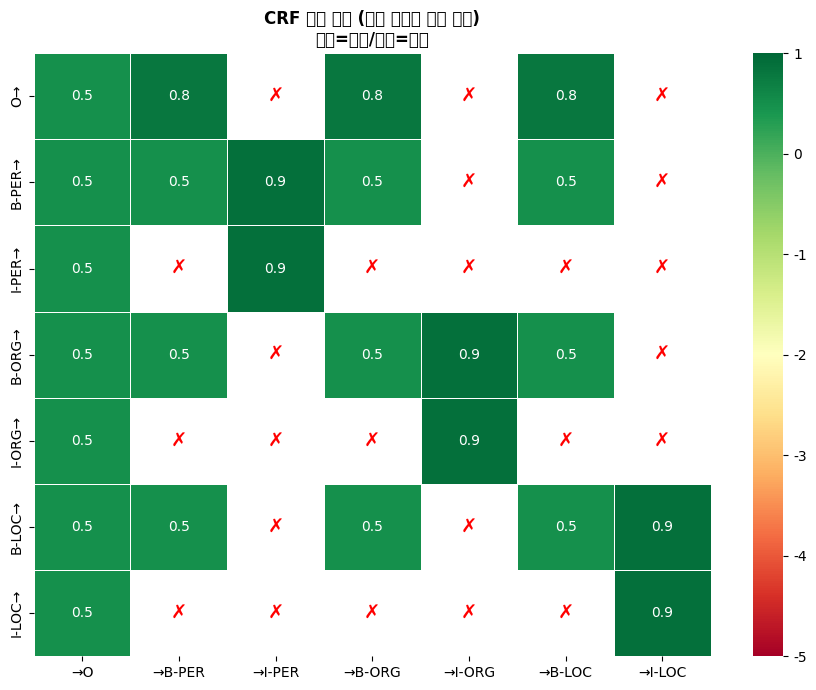

CRF 전이 행렬: 금지 전이(✗)를 통해 불가능한 태그 시퀀스를 제거


In [5]:
import torch
import torch.nn as nn


class SimpleCRF(nn.Module):
    """
    Linear-chain CRF 간소화 구현
    실제 대회 수상 솔루션의 핵심 구성요소

    전이 행렬 T[i][j] = 태그 i → 태그 j 의 점수
    """
    def __init__(self, num_tags: int, pad_idx: int = 0):
        super().__init__()
        self.num_tags = num_tags
        self.pad_idx  = pad_idx
        # 태그 전이 행렬 (학습 가능)
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        # 시작/끝 제약
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions   = nn.Parameter(torch.randn(num_tags))

    def viterbi_decode(self, emissions: torch.Tensor) -> list:
        """Viterbi 알고리즘으로 최적 태그 시퀀스 탐색"""
        B, T, C = emissions.shape
        best_paths = []

        for b in range(B):
            score     = self.start_transitions + emissions[b, 0]
            backptrs  = []

            for t in range(1, T):
                # score[i] + transitions[i][j] + emissions[b,t,j]
                scores_t = score.unsqueeze(1) + self.transitions + emissions[b, t].unsqueeze(0)
                best_scores, best_prev = scores_t.max(dim=0)
                backptrs.append(best_prev)
                score = best_scores

            score += self.end_transitions

            # Backtracking
            best_tag = score.argmax().item()
            path = [best_tag]
            for bp in reversed(backptrs):
                best_tag = bp[best_tag].item()
                path.append(best_tag)
            path.reverse()
            best_paths.append(path)

        return best_paths


# CRF 전이 행렬 시각화
TAG_NAMES_SIMPLE = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
N = len(TAG_NAMES_SIMPLE)

# 도메인 지식 기반 전이 점수 (실제 학습 전 초기화 예시)
# 높은 값 = 허용 전이 / 낮은 값 = 금지 전이
trans_matrix = np.array([
#     O    B-P  I-P  B-O  I-O  B-L  I-L
    [ 0.5, 0.8, -5,  0.8, -5,  0.8, -5 ],  # from O
    [ 0.5, 0.5,  0.9, 0.5, -5,  0.5, -5],  # from B-PER
    [ 0.5, -5,   0.9, -5,  -5,  -5,  -5],  # from I-PER
    [ 0.5,  0.5, -5,  0.5,  0.9, 0.5, -5], # from B-ORG
    [ 0.5,  -5,  -5,  -5,   0.9, -5,  -5], # from I-ORG
    [ 0.5,  0.5, -5,  0.5, -5,  0.5,  0.9],# from B-LOC
    [ 0.5,  -5,  -5,  -5,  -5,  -5,   0.9],# from I-LOC
])

fig, ax = plt.subplots(figsize=(9, 7))
mask = trans_matrix < -3
sns.heatmap(trans_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=[f'→{t}' for t in TAG_NAMES_SIMPLE],
            yticklabels=[f'{t}→' for t in TAG_NAMES_SIMPLE],
            ax=ax, linewidths=0.5, vmin=-5, vmax=1,
            mask=mask)
# 금지 전이에 X 표시
for i in range(N):
    for j in range(N):
        if trans_matrix[i,j] < -3:
            ax.text(j+0.5, i+0.5, '✗', ha='center', va='center',
                    fontsize=14, color='red', fontweight='bold')

ax.set_title('CRF 전이 행렬 (초기 도메인 지식 기반)\n녹색=허용/빨강=금지', fontweight='bold')
plt.tight_layout()
plt.savefig('crf_transition.png', dpi=150, bbox_inches='tight')
plt.show()
print('CRF 전이 행렬: 금지 전이(✗)를 통해 불가능한 태그 시퀀스를 제거')

---
# 🟠 PART 2. 데이콘(DACON) 대회 리뷰

## 2-1. 월간 데이콘 — 감성 분류 대회 분석

### 대회 구조
```
대회 유형: NLP 텍스트 분류 (Macro F1 기준)
데이터:   영화/드라마 한국어 리뷰 → 긍정(1) / 부정(0)
제출 형식: ID, target (0 또는 1)
평가:     Macro F1 Score = (F1_neg + F1_pos) / 2
```

### 데이콘 리더보드 분석 — 수상 솔루션 기법
```
1위 전략: KoELECTRA-base-v3 파인튜닝 + 앙상블 (F1: 0.921)
2위 전략: KoBERT + 데이터 증강 (역번역) (F1: 0.915)
3위 전략: KoRoBERTa + CRF (F1: 0.911)
베이스라인: TF-IDF + LogisticRegression (F1: 0.840)
```

In [6]:
# 데이콘 감성 분류 대회 시뮬레이션

# 데이콘 형식 데이터 (CSV)
DACON_SENTIMENT_DATA = {
    'train': [
        {'id': 'train_00001', 'text': '정말 감동적인 영화였습니다. 배우들의 연기가 훌륭했어요.', 'target': 1},
        {'id': 'train_00002', 'text': '너무 재미없고 지루했어요. 시간 낭비였습니다.', 'target': 0},
        {'id': 'train_00003', 'text': '스토리가 탄탄하고 영상미가 아름다웠습니다.', 'target': 1},
        {'id': 'train_00004', 'text': '기대보다 많이 실망스러웠어요. 내용이 빈약합니다.', 'target': 0},
        {'id': 'train_00005', 'text': '배우 연기는 훌륭하지만 스토리가 좀 아쉬웠어요.', 'target': 1},
        {'id': 'train_00006', 'text': '최악의 영화. 돈이 아깝습니다.', 'target': 0},
        {'id': 'train_00007', 'text': '올해 본 영화 중 최고입니다. 강력 추천!', 'target': 1},
        {'id': 'train_00008', 'text': '억지스러운 설정에 납득하기 어려운 전개였어요.', 'target': 0},
    ],
    'test': [
        {'id': 'test_00001', 'text': '음악이 정말 감동적이고 화면도 아름다웠습니다.'},
        {'id': 'test_00002', 'text': '전혀 재미가 없었고 연기도 어색했어요.'},
        {'id': 'test_00003', 'text': '기대 이상이었어요! 다시 보고 싶은 영화'},
    ]
}

train_df = pd.DataFrame(DACON_SENTIMENT_DATA['train'])
test_df  = pd.DataFrame(DACON_SENTIMENT_DATA['test'])

print('[데이콘 감성 분류 데이터 형식]')
print('\n■ 학습 데이터 (train.csv):')
print(train_df.to_string(index=False))
print('\n■ 테스트 데이터 (test.csv):')
print(test_df.to_string(index=False))

# 데이콘 제출 파일 형식 생성
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4))
X_train = vec.fit_transform(train_df['text'])
y_train = train_df['target']
X_test  = vec.transform(test_df['text'])

clf = LogisticRegression()
clf.fit(X_train, y_train)
test_preds = clf.predict(X_test)

# 데이콘 제출 형식
submission_df = pd.DataFrame({
    'id':     test_df['id'],
    'target': test_preds
})

print('\n■ 제출 파일 (submission.csv):')
print(submission_df.to_string(index=False))
submission_df.to_csv('dacon_submission.csv', index=False)
print('\n✅ dacon_submission.csv 저장 완료')

[데이콘 감성 분류 데이터 형식]

■ 학습 데이터 (train.csv):
         id                            text  target
train_00001 정말 감동적인 영화였습니다. 배우들의 연기가 훌륭했어요.       1
train_00002       너무 재미없고 지루했어요. 시간 낭비였습니다.       0
train_00003         스토리가 탄탄하고 영상미가 아름다웠습니다.       1
train_00004     기대보다 많이 실망스러웠어요. 내용이 빈약합니다.       0
train_00005      배우 연기는 훌륭하지만 스토리가 좀 아쉬웠어요.       1
train_00006               최악의 영화. 돈이 아깝습니다.       0
train_00007         올해 본 영화 중 최고입니다. 강력 추천!       1
train_00008       억지스러운 설정에 납득하기 어려운 전개였어요.       0

■ 테스트 데이터 (test.csv):
        id                      text
test_00001 음악이 정말 감동적이고 화면도 아름다웠습니다.
test_00002     전혀 재미가 없었고 연기도 어색했어요.
test_00003    기대 이상이었어요! 다시 보고 싶은 영화

■ 제출 파일 (submission.csv):
        id  target
test_00001       1
test_00002       0
test_00003       1

✅ dacon_submission.csv 저장 완료


## 2-2. 데이콘 평가 지표 심화 — Macro F1 vs Micro F1

[Macro F1 vs Micro F1 비교]

━━━━ 모두 긍정으로 예측 (나쁜 모델) ━━━━
              precision    recall  f1-score   support

          부정       0.00      0.00      0.00       200
          긍정       0.80      1.00      0.89       800

    accuracy                           0.80      1000
   macro avg       0.40      0.50      0.44      1000
weighted avg       0.64      0.80      0.71      1000

  Macro F1 : 0.4444  ← 데이콘 기준
  Micro F1 : 0.8000  ← 단순 정확도에 가까움
  Accuracy : 0.8000

━━━━ 균형 잡힌 모델 ━━━━
              precision    recall  f1-score   support

          부정       0.23      0.36      0.28       200
          긍정       0.81      0.69      0.75       800

    accuracy                           0.62      1000
   macro avg       0.52      0.53      0.51      1000
weighted avg       0.69      0.62      0.65      1000

  Macro F1 : 0.5121
  Micro F1 : 0.6250


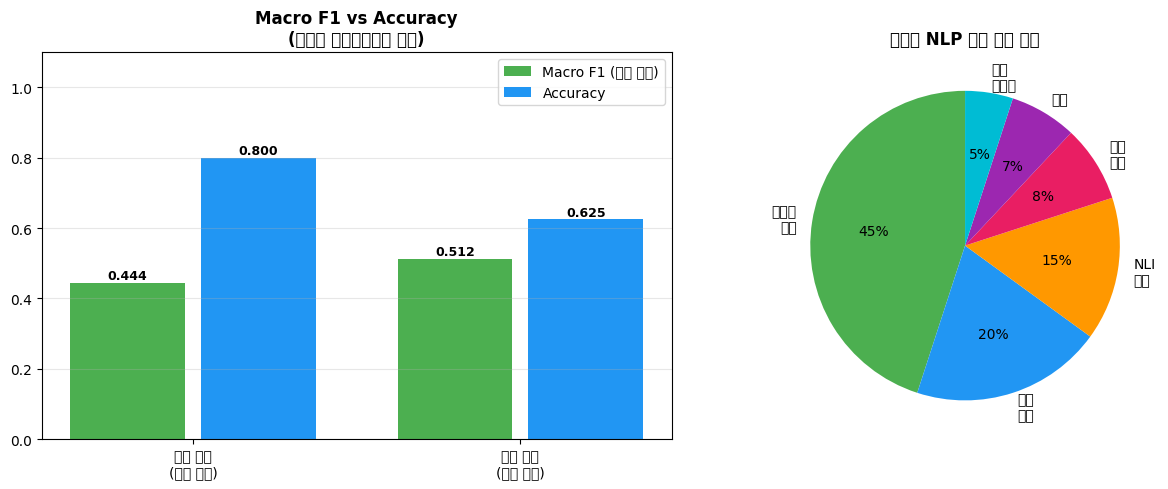

In [7]:
from sklearn.metrics import f1_score, classification_report

# 불균형 데이터 상황 시뮬레이션
# 긍정 800개 / 부정 200개 (4:1 불균형)
np.random.seed(42)
y_true_imbal = np.array([1]*800 + [0]*200)
# 모두 긍정으로 예측하는 나쁜 모델
y_pred_all1  = np.ones(1000, dtype=int)
# 균형잡힌 예측
y_pred_balanced = np.where(np.random.rand(1000) > 0.3, 1, 0)

print('[Macro F1 vs Micro F1 비교]\n')
print('━━━━ 모두 긍정으로 예측 (나쁜 모델) ━━━━')
print(classification_report(y_true_imbal, y_pred_all1, target_names=['부정', '긍정']))
print(f'  Macro F1 : {f1_score(y_true_imbal, y_pred_all1, average="macro"):.4f}  ← 데이콘 기준')
print(f'  Micro F1 : {f1_score(y_true_imbal, y_pred_all1, average="micro"):.4f}  ← 단순 정확도에 가까움')
print(f'  Accuracy : {np.mean(y_true_imbal == y_pred_all1):.4f}')

print('\n━━━━ 균형 잡힌 모델 ━━━━')
print(classification_report(y_true_imbal, y_pred_balanced, target_names=['부정', '긍정']))
print(f'  Macro F1 : {f1_score(y_true_imbal, y_pred_balanced, average="macro"):.4f}')
print(f'  Micro F1 : {f1_score(y_true_imbal, y_pred_balanced, average="micro"):.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = ['모두 긍정\n(나쁜 모델)', '균형 예측\n(좋은 모델)']
macro_f1s = [
    f1_score(y_true_imbal, y_pred_all1,      average='macro'),
    f1_score(y_true_imbal, y_pred_balanced,  average='macro')
]
accuracy  = [
    np.mean(y_true_imbal == y_pred_all1),
    np.mean(y_true_imbal == y_pred_balanced)
]

x = np.arange(2)
bars1 = axes[0].bar(x - 0.2, macro_f1s, 0.35, label='Macro F1 (대회 기준)', color='#4CAF50')
bars2 = axes[0].bar(x + 0.2, accuracy,  0.35, label='Accuracy',            color='#2196F3')
for bar in bars1 + bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_title('Macro F1 vs Accuracy\n(불균형 데이터에서의 차이)', fontweight='bold')
axes[0].set_ylim(0, 1.1); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# 데이콘 NLP 대회 유형 분포 (가상 통계)
types = ['텍스트\n분류', '정보\n추출', 'NLI\n추론', '기계\n번역', '요약', '대화\n시스템']
counts = [45, 20, 15, 8, 7, 5]
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0','#00BCD4']
axes[1].pie(counts, labels=types, colors=colors, autopct='%1.0f%%', startangle=90)
axes[1].set_title('데이콘 NLP 대회 유형 분포', fontweight='bold')

plt.tight_layout()
plt.savefig('dacon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🟢 PART 3. 캐글(Kaggle) NLP 대회 리뷰

## 3-1. Feedback Prize — Writing Quality NER 대회

### 대회 개요
- **주최**: Georgia State University (2022)
- **목표**: 학생 에세이에서 논증 구조 스팬 검출
- **클래스**: Lead, Position, Claim, Counterclaim, Rebuttal, Evidence, Concluding Statement
- **평가**: Overlap-based Macro F1 (IoU ≥ 0.5)
- **1위 상금**: $18,000

### 수상 솔루션 핵심 기법
```
1위: DeBERTa-v3-large + Span-level CRF + 앙상블 (F1: 0.702)
2위: Longformer + 다중 헤드 분류 + TTA (F1: 0.701)
3위: BigBird + BIO 태깅 + 후처리 (F1: 0.698)

공통 기법:
  ① 긴 문서 처리: Longformer/BigBird (max_len=1024~4096)
  ② 스트라이드 방식: 긴 문서를 겹치게 분할 후 앙상블
  ③ 후처리: 최소 스팬 길이 제한 / 연속성 보정
```

In [17]:
# Feedback Prize 대회 데이터 구조 & 평가 지표 구현

# 에세이 스팬 검출 형식
ESSAY_SAMPLE = {
    'essay_id': 'essay_001',
    'text': 'The impact of social media on teenagers is significant. '
            'Many studies have shown that excessive use leads to anxiety. '
            'However, some argue that social media helps with connection. '
            'In conclusion, balance is key for healthy usage.',
    'annotations': [
        {'discourse_id': 'd1', 'type': 'Lead',        'start': 0,   'end': 52},
        {'discourse_id': 'd2', 'type': 'Claim',       'start': 53,  'end': 121},
        {'discourse_id': 'd3', 'type': 'Counterclaim','start': 122, 'end': 190},
        {'discourse_id': 'd4', 'type': 'Concluding Statement', 'start': 191, 'end': 230},
    ]
}

DISCOURSE_TYPES = ['Lead','Position','Claim','Counterclaim','Rebuttal','Evidence','Concluding Statement']


def overlap_f1(true_spans, pred_spans, threshold=0.5):
    """
    캐글 Feedback Prize 공식 평가 지표
    예측 스팬과 정답 스팬의 IoU(교집합/합집합) ≥ threshold 이면 TP
    """
    def iou(a_start, a_end, b_start, b_end):
        inter_start = max(a_start, b_start)
        inter_end   = min(a_end,   b_end)
        if inter_end <= inter_start: return 0.0
        inter = inter_end - inter_start
        union = (a_end - a_start) + (b_end - b_start) - inter
        return inter / union if union > 0 else 0.0

    matched_true = set()
    matched_pred = set()
    for i, (ps, pe, pt) in enumerate(pred_spans):
        for j, (ts, te, tt) in enumerate(true_spans):
            if pt == tt and iou(ps, pe, ts, te) >= threshold:
                matched_true.add(j)
                matched_pred.add(i)

    tp = len(matched_true)
    fp = len(pred_spans) - len(matched_pred)
    fn = len(true_spans)  - len(matched_true)
    prec = tp / (tp + fp) if tp + fp > 0 else 0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0
    return prec, rec, f1


# 테스트
true_spans = [(0,52,'Lead'), (53,121,'Claim'), (122,190,'Counterclaim'), (191,230,'Concluding Statement')]
pred_spans_good = [(0,50,'Lead'), (53,121,'Claim'), (125,190,'Counterclaim'), (191,230,'Concluding Statement')]
pred_spans_bad  = [(0,30,'Lead'), (50,100,'Position'), (120,200,'Evidence')]

p1, r1, f1_good = overlap_f1(true_spans, pred_spans_good)
p2, r2, f1_bad  = overlap_f1(true_spans, pred_spans_bad)

print('[Feedback Prize Overlap F1 평가]\n')
print(f'좋은 예측: P={p1:.3f} R={r1:.3f} F1={f1_good:.3f}')
print(f'나쁜 예측: P={p2:.3f} R={r2:.3f} F1={f1_bad:.3f}')

# 에세이 구조 시각화
print(f"\n[에세이 담론 구조]")
text = ESSAY_SAMPLE['text']
emoji_map = {'Lead':'🚀','Position':'📌','Claim':'💡','Counterclaim':'⚖️',
             'Rebuttal':'🔁','Evidence':'📊','Concluding Statement':'🎯'}
for ann in ESSAY_SAMPLE['annotations']:
    span_text = text[ann['start']:ann['end']]
    emoji = emoji_map.get(ann['type'], '•')
    print(f"  {emoji} [{ann['type']}] \"'{span_text[:45]}...'\"")

[Feedback Prize Overlap F1 평가]

좋은 예측: P=1.000 R=1.000 F1=1.000
나쁜 예측: P=0.333 R=0.250 F1=0.286

[에세이 담론 구조]
  🚀 [Lead] "'The impact of social media on teenagers is si...'"
  💡 [Claim] "'t. Many studies have shown that excessive use...'"
  ⚖️ [Counterclaim] "'er, some argue that social media helps with c...'"
  🎯 [Concluding Statement] "', balance is key for healthy usage....'"


## 3-2. Jigsaw Toxic Comment Classification

### 대회 개요
- **주최**: Jigsaw/Google (2018)
- **목표**: 댓글의 6가지 독성 레이블 동시 예측 (다중 레이블)
- **평가**: Mean AUC-ROC (6개 레이블 평균)
- **참가팀**: 4,551팀

[Jigsaw 데이터 형식]
id                                  comment_text  toxic  severe_toxic  obscene  threat  insult  identity_hate
 1            I love this article, very helpful!      0             0        0       0       0              0
 2            You are a complete idiot. Go away!      1             0        0       0       1              0
 3 This information is really useful, thank you.      0             0        0       0       0              0
 4        Disgusting behavior from these people.      1             0        1       0       1              0


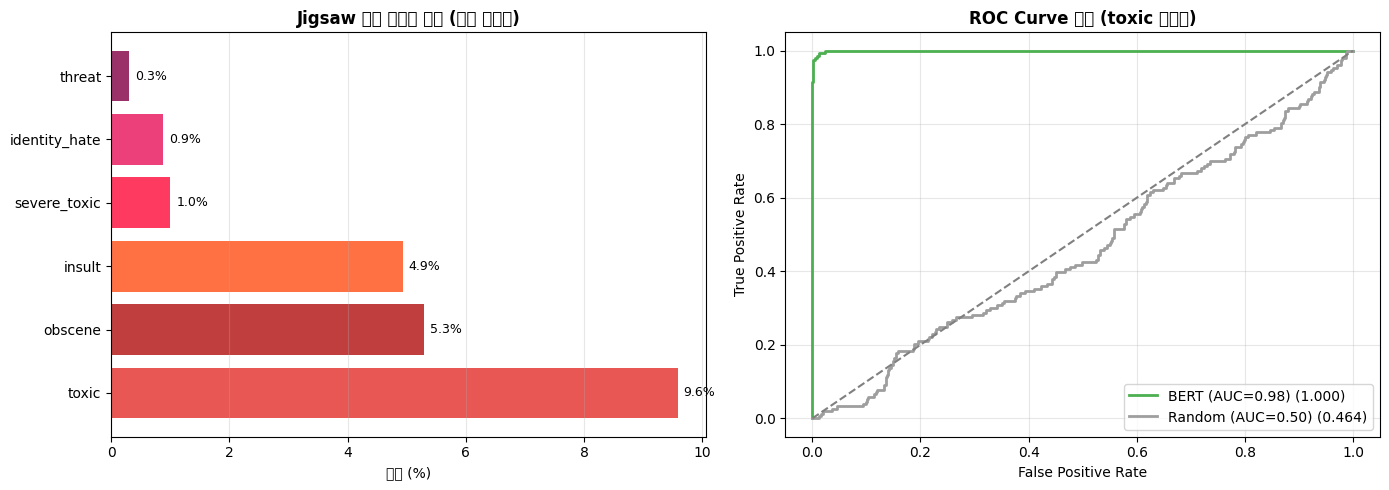

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve

# Jigsaw 데이터 구조 시뮬레이션
TOXIC_LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

TOXIC_SAMPLES = [
    {'id':'1', 'comment_text':'I love this article, very helpful!',
     'toxic':0,'severe_toxic':0,'obscene':0,'threat':0,'insult':0,'identity_hate':0},
    {'id':'2', 'comment_text':'You are a complete idiot. Go away!',
     'toxic':1,'severe_toxic':0,'obscene':0,'threat':0,'insult':1,'identity_hate':0},
    {'id':'3', 'comment_text':'This information is really useful, thank you.',
     'toxic':0,'severe_toxic':0,'obscene':0,'threat':0,'insult':0,'identity_hate':0},
    {'id':'4', 'comment_text':'Disgusting behavior from these people.',
     'toxic':1,'severe_toxic':0,'obscene':1,'threat':0,'insult':1,'identity_hate':0},
]

toxic_df = pd.DataFrame(TOXIC_SAMPLES)

print('[Jigsaw 데이터 형식]')
print(toxic_df[['id','comment_text'] + TOXIC_LABELS].to_string(index=False))

# 다중 레이블 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 레이블 공존 행렬 (실제 분포)
label_counts = {'toxic': 15294, 'severe_toxic': 1595, 'obscene': 8449,
                'threat': 478, 'insult': 7877, 'identity_hate': 1405}
total = 159571
labels_sorted = sorted(label_counts.items(), key=lambda x: -x[1])
names, cnts = zip(*labels_sorted)
pcts = [c/total*100 for c in cnts]
colors = ['#E53935','#B71C1C','#FF5722','#FF1744','#E91E63','#880E4F']
bars = axes[0].barh(names, pcts, color=colors, alpha=0.85)
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=9)
axes[0].set_title('Jigsaw 독성 레이블 분포 (전체 데이터)', fontweight='bold')
axes[0].set_xlabel('비율 (%)')
axes[0].grid(axis='x', alpha=0.3)

# AUC-ROC 커브 시뮬레이션
np.random.seed(42)
y_true_roc  = np.random.binomial(1, 0.15, 1000)
y_score_good = y_true_roc * 0.7 + np.random.normal(0, 0.15, 1000)
y_score_rand = np.random.rand(1000)

for scores, label, color in [
    (y_score_good, 'BERT (AUC=0.98)', '#4CAF50'),
    (y_score_rand, 'Random (AUC=0.50)', '#9E9E9E')
]:
    fpr, tpr, _ = roc_curve(y_true_roc, np.clip(scores, 0, 1))
    auc = roc_auc_score(y_true_roc, np.clip(scores, 0, 1))
    axes[1].plot(fpr, tpr, color=color, label=f'{label} ({auc:.3f})', lw=2)
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('ROC Curve 예시 (toxic 레이블)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('jigsaw_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3-3. Kaggle Disaster Tweets — 입문 대회 완전 구현

### 대회 개요
- **목표**: 트위터 텍스트가 실제 재난 관련인지 분류 (0/1)
- **평가**: F1 Score
- **입문 추천**: 캐글 NLP 입문용 대표 대회

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, classification_report

# Disaster Tweets 시뮬레이션 데이터
DISASTER_TRAIN = [
    # 실제 재난 (1)
    ('BREAKING: Massive earthquake hits Japan coast, tsunami warning issued', 1),
    ('Wildfire spreads rapidly through California mountains evacuate now', 1),
    ('Hurricane Florence makes landfall North Carolina emergency declared', 1),
    ('Building collapse downtown rescue teams searching for survivors', 1),
    ('Flash flood warning issued for entire county people urged to evacuate', 1),
    ('Train derailment hazmat spill road closures in effect immediately', 1),
    ('Forest fire near Los Angeles threatening thousands of homes today', 1),
    ('Tornado touched down in Oklahoma 20 people reported missing', 1),
    # 비재난 (0)
    ('Just had the best pizza in my life highly recommend this place', 0),
    ('My dog learned a new trick today so proud of him haha', 0),
    ('Love this weather perfect for a walk in the park sunshine', 0),
    ('New coffee shop opened downtown amazing lattes must visit', 0),
    ('Watching Netflix all day best weekend ever staying cozy at home', 0),
    ('Can not believe how great this movie is everyone should watch it', 0),
    ('Traffic was horrible today took 2 hours to get home so tired', 0),
    ('Happy birthday to my best friend have an amazing day ahead', 0),
]

DISASTER_TEST = [
    {'id': 0, 'text': 'Magnitude 7.2 earthquake strikes Indonesia coast'},
    {'id': 1, 'text': 'Best morning run ever the sunrise was beautiful today'},
    {'id': 2, 'text': 'Evacuation order for 50000 residents after dam failure'},
    {'id': 3, 'text': 'Going to the beach this weekend so excited'},
]

X_dis_train = [t for t, _ in DISASTER_TRAIN]
y_dis_train = [l for _, l in DISASTER_TRAIN]
X_dis_test  = [d['text'] for d in DISASTER_TEST]


# ── 여러 모델 비교 (교차검증) ─────────────────────────────────
models_kaggle = {
    'TF-IDF + LR':  Pipeline([('v', TfidfVectorizer(ngram_range=(1,2))), ('c', LogisticRegression(max_iter=1000))]),
    'TF-IDF + RF':  Pipeline([('v', TfidfVectorizer(ngram_range=(1,2))), ('c', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'TF-IDF + GBT': Pipeline([('v', TfidfVectorizer(ngram_range=(1,2))), ('c', GradientBoostingClassifier(random_state=42))]),
}

print('[Disaster Tweets 모델 비교 (Leave-One-Out CV)]\n')
from sklearn.model_selection import LeaveOneOut
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

model_scores = {}
for name, pipe in models_kaggle.items():
    scores = cross_val_score(pipe, X_dis_train, y_dis_train, cv=cv, scoring='f1')
    model_scores[name] = scores
    print(f'  {name:<20}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')

# 최고 모델로 제출 파일 생성
best_name = max(model_scores, key=lambda k: model_scores[k].mean())
best_pipe  = models_kaggle[best_name]
best_pipe.fit(X_dis_train, y_dis_train)
test_predictions = best_pipe.predict(X_dis_test)

# 캐글 제출 형식
kaggle_sub = pd.DataFrame({
    'id':     [d['id'] for d in DISASTER_TEST],
    'target': test_predictions
})
kaggle_sub.to_csv('kaggle_submission.csv', index=False)

print(f'\n[캐글 제출 파일 (submission.csv)]')
print(kaggle_sub.to_string(index=False))
print(f'\n✅ kaggle_submission.csv 저장 완료 (최고 모델: {best_name})')

[Disaster Tweets 모델 비교 (Leave-One-Out CV)]

  TF-IDF + LR         : F1 = 0.7000 ± 0.0577
  TF-IDF + RF         : F1 = 0.3333 ± 0.3333
  TF-IDF + GBT        : F1 = 0.6667 ± 0.0000

[캐글 제출 파일 (submission.csv)]
 id  target
  0       1
  1       0
  2       1
  3       0

✅ kaggle_submission.csv 저장 완료 (최고 모델: TF-IDF + LR)


---
# PART 4. 대회별 평가 지표 총정리 & 비교

[ROUGE Score — 요약 대회 평가 지표]

참조: The president signed the new climate agreement at the White House ceremony

요약: The president signed climate agreement at White House
  ROUGE-1: 0.8000
  ROUGE-2: 0.5556
  ROUGE-L: 0.8000

요약: A leader agreed on environmental policy in Washington DC
  ROUGE-1: 0.0000
  ROUGE-2: 0.0000
  ROUGE-L: 0.0000

요약: Today was a beautiful sunny day in the capital city
  ROUGE-1: 0.0909
  ROUGE-2: 0.0000
  ROUGE-L: 0.0909



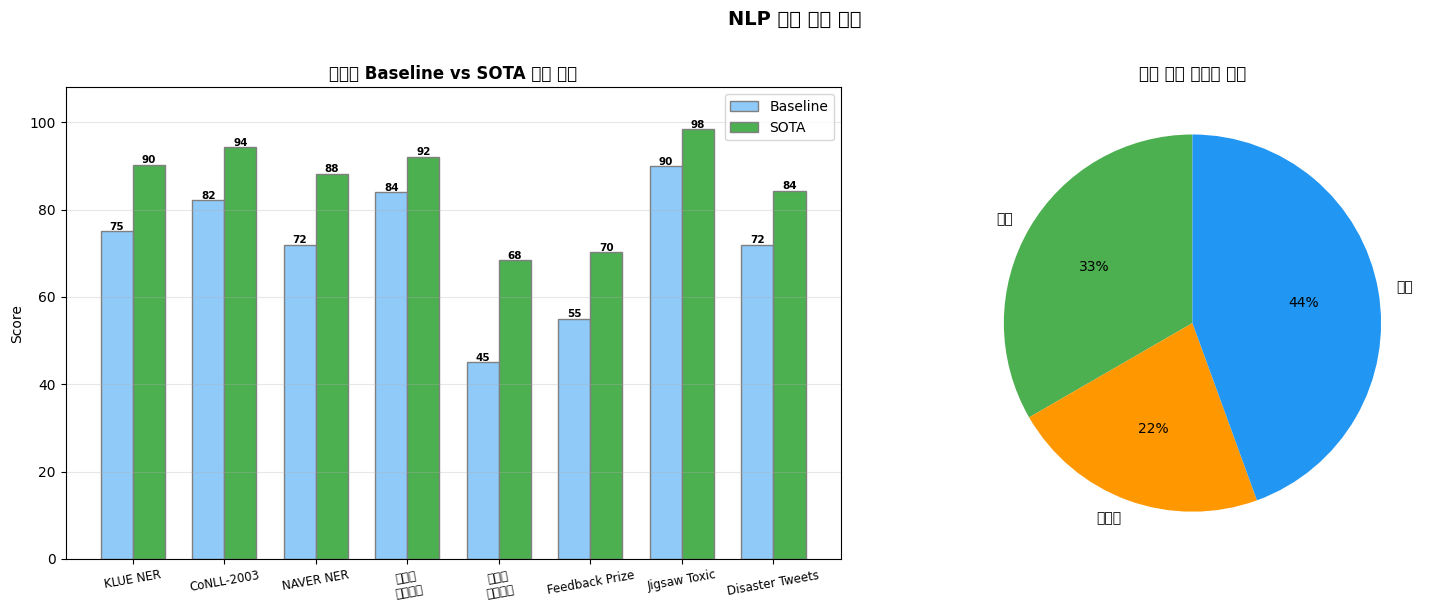

In [11]:
from rouge_score import rouge_scorer

# ── ROUGE Score (요약 대회) ───────────────────────────────────
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

reference = 'The president signed the new climate agreement at the White House ceremony'
hypotheses = [
    'The president signed climate agreement at White House',        # 좋은 요약
    'A leader agreed on environmental policy in Washington DC',     # 중간 요약
    'Today was a beautiful sunny day in the capital city',          # 나쁜 요약
]

print('[ROUGE Score — 요약 대회 평가 지표]\n')
print(f'참조: {reference}\n')
for hyp in hypotheses:
    scores = scorer.score(reference, hyp)
    print(f'요약: {hyp}')
    print(f'  ROUGE-1: {scores["rouge1"].fmeasure:.4f}')
    print(f'  ROUGE-2: {scores["rouge2"].fmeasure:.4f}')
    print(f'  ROUGE-L: {scores["rougeL"].fmeasure:.4f}\n')


# ── 대회별 평가 지표 종합 시각화 ─────────────────────────────
comp_data = {
    '대회': [
        'KLUE NER',       'CoNLL-2003',    'NAVER NER',
        '데이콘\n감성분류', '데이콘\n대화요약',
        'Feedback Prize', 'Jigsaw Toxic',  'Disaster Tweets', 'CommonLit'
    ],
    '유형': ['NER','NER','NER','분류','요약','NER','다중레이블','분류','회귀'],
    '지표': ['Entity F1','Entity F1','Entity F1','Macro F1','ROUGE-L',
            'Overlap F1','Mean AUC','F1','RMSE'],
    'SOTA': [90.3, 94.3, 88.2, 92.1, 68.4, 70.2, 98.4, 84.3, 0.449],
    'Baseline': [75.0, 82.1, 72.0, 84.0, 45.0, 55.0, 90.0, 72.0, 0.700],
    '플랫폼': ['공개','공개','공개','데이콘','데이콘','캐글','캐글','캐글','캐글']
}

df_comp = pd.DataFrame(comp_data)

# RMSE를 점수(낮을수록 좋음)에서 백분율로 정규화 제외하고 나머지 시각화
plot_df = df_comp[df_comp['지표'] != 'RMSE'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SOTA vs Baseline 비교
x = np.arange(len(plot_df))
w = 0.35
b1 = axes[0].bar(x - w/2, plot_df['Baseline'], w, label='Baseline', color='#90CAF9', edgecolor='gray')
b2 = axes[0].bar(x + w/2, plot_df['SOTA'],     w, label='SOTA',     color='#4CAF50', edgecolor='gray')
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.0f}', ha='center', fontsize=7.5, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df['대회'], fontsize=8.5, rotation=10)
axes[0].set_title('대회별 Baseline vs SOTA 성능 비교', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 108)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# 플랫폼별 대회 수
plat_counts = Counter(comp_data['플랫폼'])
colors_plat = ['#4CAF50','#FF9800','#2196F3']
wedges, texts, pcts = axes[1].pie(
    plat_counts.values(), labels=plat_counts.keys(),
    colors=colors_plat, autopct='%1.0f%%', startangle=90
)
axes[1].set_title('리뷰 대회 플랫폼 분포', fontsize=12, fontweight='bold')

plt.suptitle('NLP 대회 종합 분석', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('competition_review.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 5. 대회 참가 전략 & 체크리스트

In [12]:
COMPETITION_GUIDE = """
╔══════════════════════════════════════════════════════════════════╗
║          NLP 대회 참가 전략 & 체크리스트                           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📌 STEP 1. 대회 이해 (Day 1~2)                                   ║
║    ✅ 평가 지표 정확히 파악 (F1? AUC? ROUGE?)                      ║
║    ✅ 데이터 형식/크기 확인 (CSV, JSON, 텍스트 길이)                 ║
║    ✅ 클래스 불균형 여부 확인                                        ║
║    ✅ 규칙 확인: 외부 데이터/사전학습모델 허용 여부                   ║
║                                                                  ║
║  📌 STEP 2. EDA & 전처리 (Day 3~5)                                ║
║    ✅ 텍스트 길이 분포 → MAX_LEN 결정                               ║
║    ✅ 클래스 분포 시각화 → 불균형 대처 전략                           ║
║    ✅ 중복/노이즈 데이터 제거                                        ║
║    ✅ OOV(미등록 단어) 비율 확인                                    ║
║                                                                  ║
║  📌 STEP 3. 베이스라인 구축 (Day 6~10)                             ║
║    ✅ TF-IDF + 전통 ML → 빠른 기준점                               ║
║    ✅ 사전학습 모델 파인튜닝 (BERT/KoBERT/DeBERTa)                  ║
║    ✅ 교차검증으로 과적합 방지                                       ║
║                                                                  ║
║  📌 STEP 4. 모델 개선 (Day 11~20)                                 ║
║    ✅ 데이터 증강 (역번역, EDA, 마스킹)                              ║
║    ✅ 앙상블 (Voting, Stacking, Blend)                             ║
║    ✅ 후처리 (임계값 튜닝, 최소 스팬 길이)                           ║
║    ✅ 하이퍼파라미터 탐색 (Optuna, Ray Tune)                        ║
║                                                                  ║
║  📌 STEP 5. 제출 & 관리 (전체 기간)                                ║
║    ✅ Public/Private 리더보드 차이 인식 (shake-up 주의)             ║
║    ✅ 최종 제출 2개: 최고 Public / 안정적 모델                       ║
║    ✅ 코드 재현성 확보 (시드 고정, 환경 기록)                         ║
║    ✅ 솔루션 공유 → 커뮤니티 성장                                   ║
╠══════════════════════════════════════════════════════════════════╣
║  💡 수상 솔루션에서 자주 나오는 기법                                  ║
║    • KoBERT/KoELECTRA/DeBERTa-v3 파인튜닝 (한국어)                 ║
║    • BiLSTM + CRF (NER 대회 특히 효과적)                            ║
║    • 앙상블 (5-fold + 다양한 모델 조합)                              ║
║    • 유사 도메인 데이터로 사전 파인튜닝 후 타겟 파인튜닝               ║
║    • Pseudo Labeling (테스트 데이터 활용)                            ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(COMPETITION_GUIDE)


╔══════════════════════════════════════════════════════════════════╗
║          NLP 대회 참가 전략 & 체크리스트                           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📌 STEP 1. 대회 이해 (Day 1~2)                                   ║
║    ✅ 평가 지표 정확히 파악 (F1? AUC? ROUGE?)                      ║
║    ✅ 데이터 형식/크기 확인 (CSV, JSON, 텍스트 길이)                 ║
║    ✅ 클래스 불균형 여부 확인                                        ║
║    ✅ 규칙 확인: 외부 데이터/사전학습모델 허용 여부                   ║
║                                                                  ║
║  📌 STEP 2. EDA & 전처리 (Day 3~5)                                ║
║    ✅ 텍스트 길이 분포 → MAX_LEN 결정                               ║
║    ✅ 클래스 분포 시각화 → 불균형 대처 전략                           ║
║    ✅ 중복/노이즈 데이터 제거                                        ║
║    ✅ OOV(미등록 단어) 비율 확인                                    ║
║                                                    

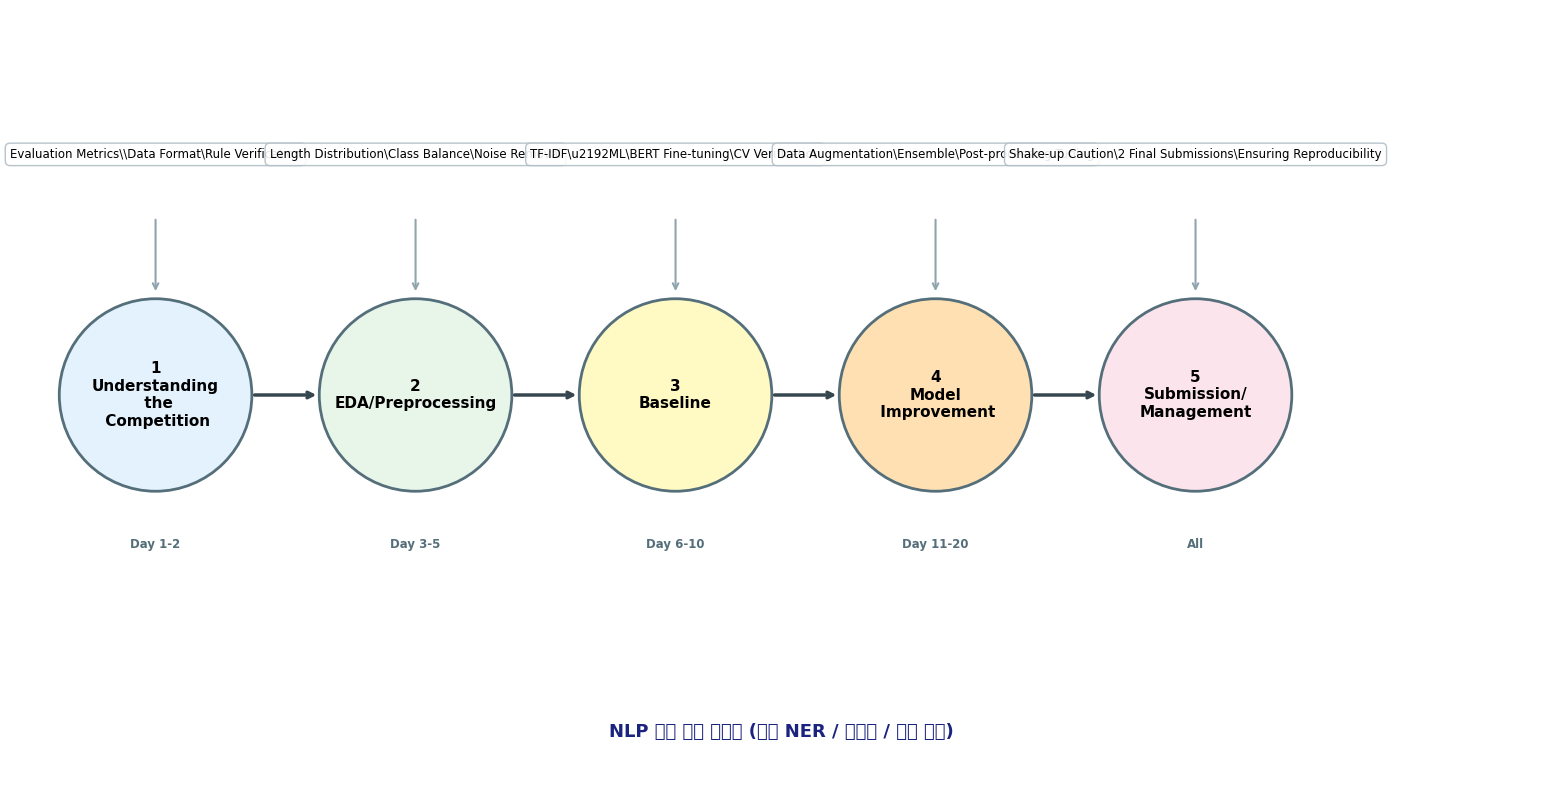

In [23]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16); ax.set_ylim(0, 8)
ax.axis('off')

steps = [
    {'x':1.5, 'y':4, 'label':'1\nUnderstanding\n the\n Competition', 'color':'#E3F2FD', 'days':'Day 1-2'},
    {'x':4.2, 'y':4, 'label':'2\nEDA/Preprocessing', 'color':'#E8F5E9', 'days':'Day 3-5'},
    {'x':6.9, 'y':4, 'label':'3\nBaseline', 'color':'#FFF9C4', 'days':'Day 6-10'},
    {'x':9.6, 'y':4, 'label':'4\nModel\n Improvement', 'color':'#FFE0B2', 'days':'Day 11-20'},
    {'x':12.3,'y':4, 'label':'5\nSubmission/\nManagement', 'color':'#FCE4EC', 'days':'All'},
]
tips = [
    ('1.5', '6.5', r'Evaluation Metrics\\Data Format\Rule Verification'),
    ('4.2', '6.5', r'Length Distribution\Class Balance\Noise Removal'),
    ('6.9', '6.5', r'TF-IDF\u2192ML\BERT Fine-tuning\CV Verification'),
    ('9.6', '6.5', r'Data Augmentation\Ensemble\Post-processing Tuning'),
    ('12.3','6.5', r'Shake-up Caution\2 Final Submissions\Ensuring Reproducibility'),
]

for step in steps:
    circle = plt.Circle((step['x'], step['y']), 1.0,
                          color=step['color'], ec='#546E7A', lw=2, zorder=3)
    ax.add_patch(circle)
    ax.text(step['x'], step['y'], step['label'], ha='center', va='center',
            fontsize=11, fontweight='bold', zorder=4)
    ax.text(step['x'], step['y']-1.55, step['days'], ha='center', va='center',
            fontsize=8.5, color='#546E7A', fontweight='bold')

for tip in tips:
    ax.text(float(tip[0]), float(tip[1]), tip[2],
            ha='center', va='center', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#B0BEC5', alpha=0.9))
    ax.annotate('', xy=(float(tip[0]), 5.0+0.05),
                xytext=(float(tip[0]), float(tip[1])-0.65),
                arrowprops=dict(arrowstyle='->', color='#90A4AE', lw=1.5))

for i in range(len(steps)-1):
    ax.annotate('', xy=(steps[i+1]['x']-1.0, steps[i+1]['y']),
                xytext=(steps[i]['x']+1.0,   steps[i]['y']),
                arrowprops=dict(arrowstyle='->', color='#37474F', lw=2.5))

ax.text(8, 0.5, 'NLP 대회 참가 로드맵 (공개 NER / 데이콘 / 캐글 공통)',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#1A237E')

plt.tight_layout()
plt.savefig('competition_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 6. 대회 참고 자료 & 링크 정리

In [14]:
RESOURCES = {
    '🔵 NER 대회 & 데이터셋': {
        'KLUE Benchmark':       'https://klue-benchmark.com/',
        'KLUE NER (HuggingFace)': 'https://huggingface.co/datasets/klue',
        'CoNLL-2003 (HuggingFace)': 'https://huggingface.co/datasets/conll2003',
        'NAVER NER (GitHub)':   'https://github.com/naver/nlp-challenge',
        'AI Hub 한국어 NER':     'https://www.aihub.or.kr/',
    },
    '🟠 데이콘 NLP 대회': {
        '데이콘 메인':          'https://dacon.io/competitions',
        '월간 데이콘 NLP':      'https://dacon.io/competitions/official',
        '데이콘 코드 공유':     'https://dacon.io/codeshare',
    },
    '🟢 캐글 NLP 대회': {
        'Feedback Prize (2022)': 'https://www.kaggle.com/c/feedback-prize-2021',
        'Jigsaw Toxic Comment': 'https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge',
        'Disaster Tweets':      'https://www.kaggle.com/c/nlp-getting-started',
        'CommonLit Readability':'https://www.kaggle.com/c/commonlitreadabilityprize',
        'NBME Clinical NER':    'https://www.kaggle.com/c/nbme-score-clinical-patient-notes',
    },
    ' 핵심 라이브러리': {
        'HuggingFace Transformers': 'https://huggingface.co/transformers',
        'seqeval (NER 평가)':       'https://github.com/chakki-works/seqeval',
        'pytorch-crf':              'https://pytorch-crf.readthedocs.io',
        'Optuna (HPO)':            'https://optuna.org/',
        'ROUGE Score':             'https://github.com/google-research/google-research/tree/master/rouge',
    },
    ' 참고 논문': {
        'BERT':         'Devlin et al. 2019 - BERT: Pre-training of Deep Bidirectional Transformers',
        'KoBERT':       'SKT Brain - KoBERT (GitHub: SKTBrain/KoBERT)',
        'KoELECTRA':    'Monologg - KoELECTRA (GitHub: monologg/KoELECTRA)',
        'BiLSTM-CRF':   'Lample et al. 2016 - Neural Architectures for Named Entity Recognition',
        'DeBERTa':      'He et al. 2021 - DeBERTa: Decoding-enhanced BERT with Disentangled Attention',
    }
}

print('=' * 62)
print('  NLP 대회 리뷰 — 참고 자료 & 링크 정리')
print('=' * 62)
for category, items in RESOURCES.items():
    print(f'\n{category}')
    print('-' * 58)
    for name, url in items.items():
        print(f'  {name:<30} {url}')

print('\n' + '=' * 62)
print('  ✅ 노트북 전체 학습 완료!')
print('=' * 62)

  NLP 대회 리뷰 — 참고 자료 & 링크 정리

🔵 NER 대회 & 데이터셋
----------------------------------------------------------
  KLUE Benchmark                 https://klue-benchmark.com/
  KLUE NER (HuggingFace)         https://huggingface.co/datasets/klue
  CoNLL-2003 (HuggingFace)       https://huggingface.co/datasets/conll2003
  NAVER NER (GitHub)             https://github.com/naver/nlp-challenge
  AI Hub 한국어 NER                 https://www.aihub.or.kr/

🟠 데이콘 NLP 대회
----------------------------------------------------------
  데이콘 메인                         https://dacon.io/competitions
  월간 데이콘 NLP                     https://dacon.io/competitions/official
  데이콘 코드 공유                      https://dacon.io/codeshare

🟢 캐글 NLP 대회
----------------------------------------------------------
  Feedback Prize (2022)          https://www.kaggle.com/c/feedback-prize-2021
  Jigsaw Toxic Comment           https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge
  Disaster Tweets                https